In [11]:
# CELL 1 — Clean Imports + Global Plot Style (run once at the top)

from google.colab import files
uploaded = files.upload()  # upload: oil_prices_2426.csv

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import scipy.stats as stats
from statsmodels.tools.sm_exceptions import ConvergenceWarning

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# tidy charts everywhere
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 140

# suppress ARIMA convergence warnings during grid search
warnings.simplefilter("ignore", ConvergenceWarning)

# reproducibility (LSTM)
tf.random.set_seed(42)
np.random.seed(42)

print("Ready. Imports + styles loaded.")

Saving oil_prices_2426.csv to oil_prices_2426 (1).csv
Ready. Imports + styles loaded.


In [2]:
# CELL 2 — Load Data + Clean Daily Time Series

df = pd.read_csv("oil_prices_2426.csv")

df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df = df.sort_values("date").set_index("date")

ts = df["price (dollars)"].astype(float)

# force daily frequency and fill missing days
ts = ts.asfreq("D")
ts = ts.interpolate(method="time").ffill().bfill()

print("Rows:", len(ts))
print("Start:", ts.index.min())
print("End  :", ts.index.max())
print("Missing values:", ts.isna().sum())

ts.head()

Rows: 500
Start: 2024-09-21 00:00:00
End  : 2026-02-02 00:00:00
Missing values: 0


,price (dollars)
date,
2024-09-21,32.10
2024-09-22,32.25
2024-09-23,31.07
2024-09-24,31.50
2024-09-25,32.21


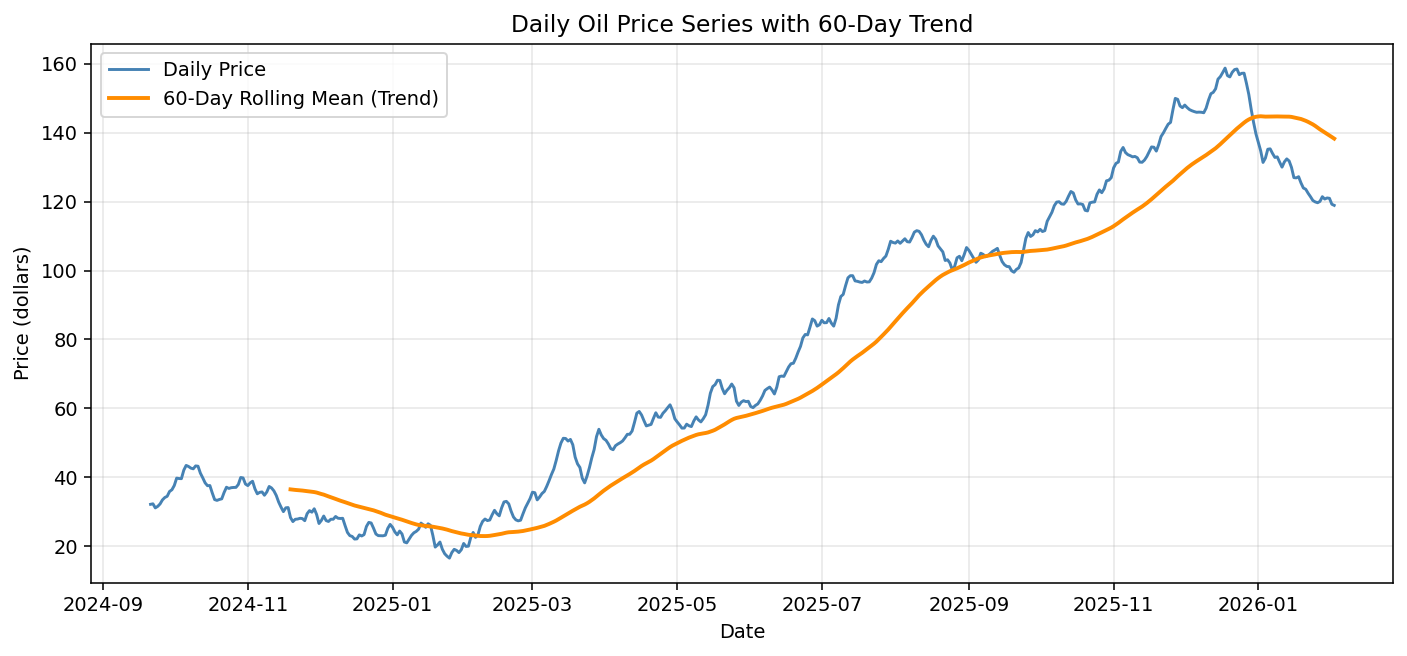

In [3]:
# CELL 3 — Exploratory Data Analysis (EDA): Time Series + 60-Day Trend

rolling_60 = ts.rolling(window=60).mean()

plt.figure()
plt.plot(ts, label="Daily Price", color="steelblue")
plt.plot(rolling_60, label="60-Day Rolling Mean (Trend)", color="darkorange", linewidth=2)

plt.title("Daily Oil Price Series with 60-Day Trend")
plt.xlabel("Date")
plt.ylabel("Price (dollars)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

date
2024-09-30    10
2024-10-31    31
2024-11-30    30
2024-12-31    31
2025-01-31    31
2025-02-28    28
2025-03-31    31
2025-04-30    30
2025-05-31    31
2025-06-30    30
2025-07-31    31
2025-08-31    31
2025-09-30    30
2025-10-31    31
2025-11-30    30
2025-12-31    31
2026-01-31    31
2026-02-28     2
Freq: ME, Name: price (dollars), dtype: int64


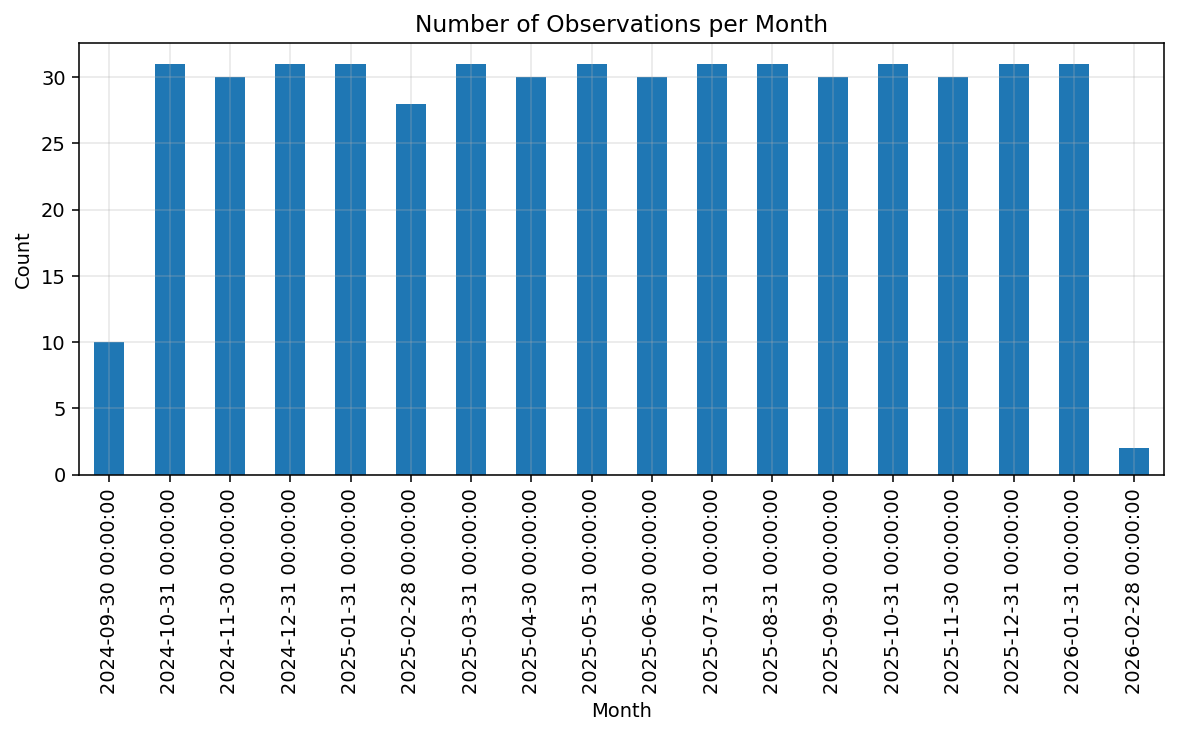

In [21]:
# Observations per Month (confirm data frequency)

monthly_counts = ts.resample("M").count()

print(monthly_counts)

plt.figure(figsize=(10,4), dpi=140)

monthly_counts.plot(kind="bar")

plt.title("Number of Observations per Month")
plt.xlabel("Month")
plt.ylabel("Count")

plt.grid(alpha=0.3)

plt.show()

ADF Statistic: -0.5462340182601634
p-value: 0.8826741397403068
Number of lags: 17
Number of observations: 482

Critical Values:
  1%: -3.4439899743408136
  5%: -2.8675550551408353
  10%: -2.569973792117904

Series likely NON-STATIONARY (fail to reject H0).


<Figure size 1680x700 with 0 Axes>

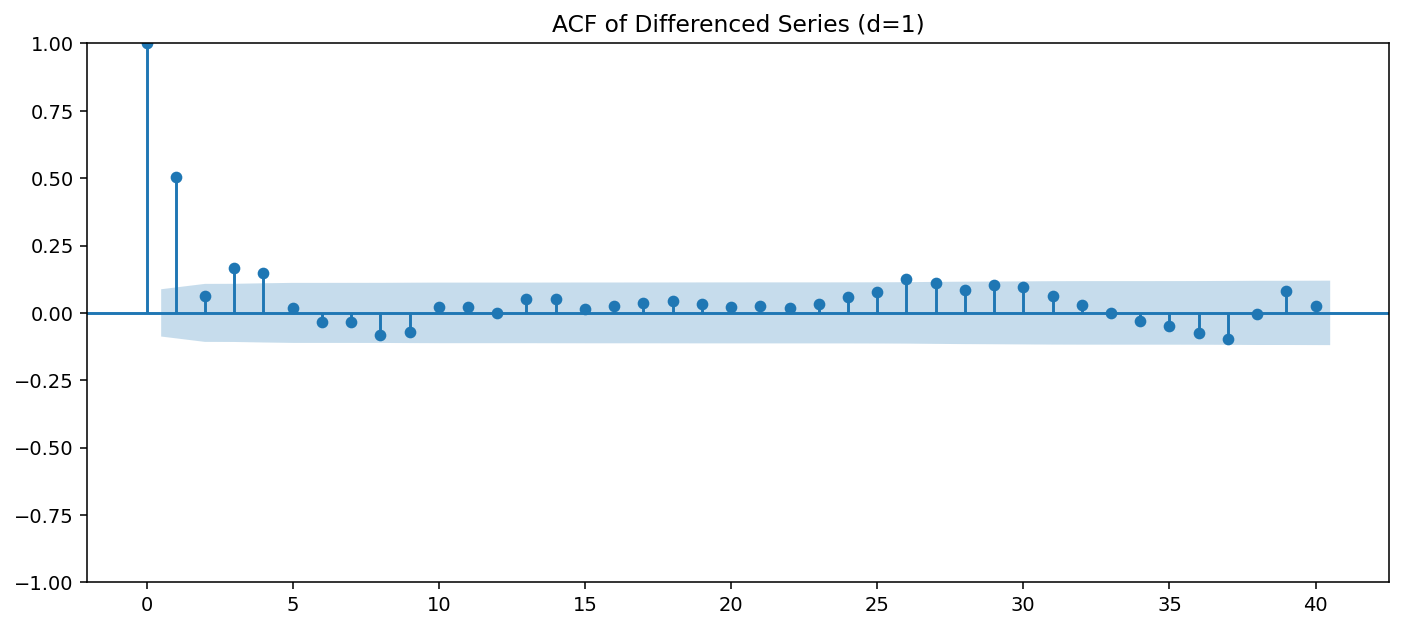

<Figure size 1680x700 with 0 Axes>

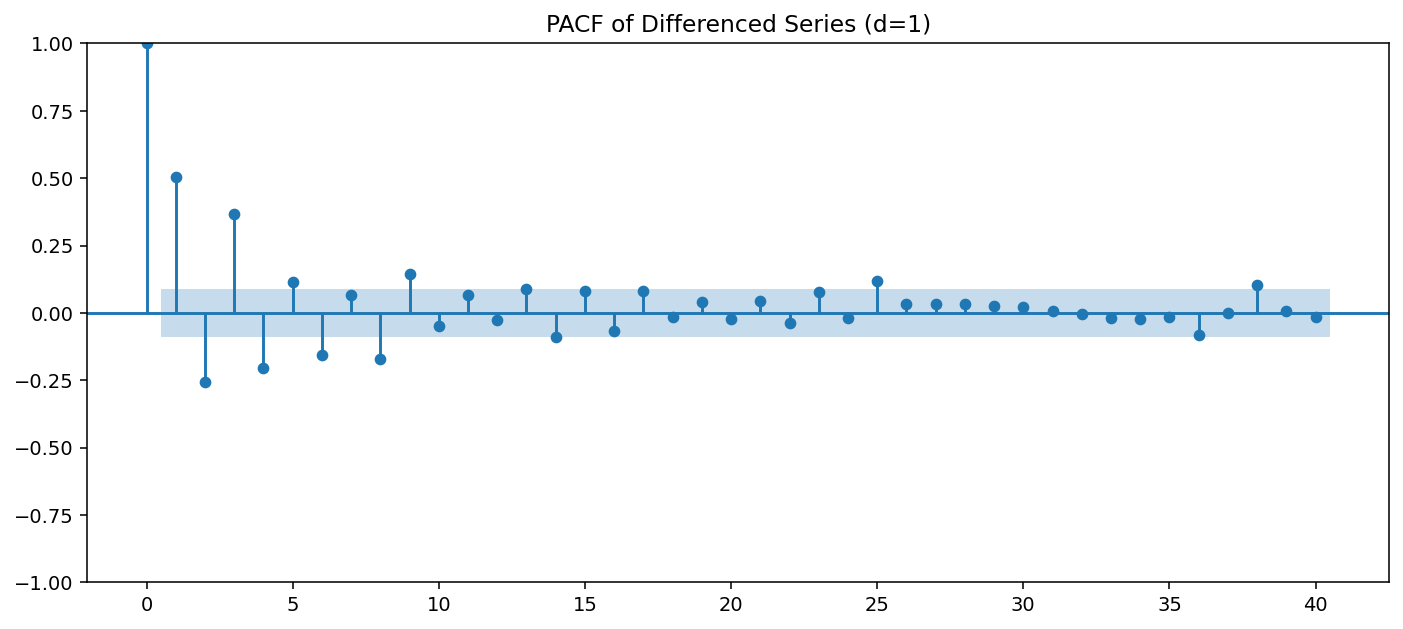

In [4]:
# CELL 4 — Stationarity Test (ADF) + ACF / PACF Diagnostics

# Augmented Dickey-Fuller test
adf_stat, pval, lags, nobs, crit_vals, _ = adfuller(ts)

print("ADF Statistic:", adf_stat)
print("p-value:", pval)
print("Number of lags:", lags)
print("Number of observations:", nobs)
print("\nCritical Values:")
for k, v in crit_vals.items():
    print(f"  {k}: {v}")

if pval < 0.05:
    print("\nSeries likely STATIONARY (reject H0).")
else:
    print("\nSeries likely NON-STATIONARY (fail to reject H0).")

# Difference once for visualization of correlations
ts_diff = ts.diff().dropna()

plt.figure()
plot_acf(ts_diff, lags=40)
plt.title("ACF of Differenced Series (d=1)")
plt.show()

plt.figure()
plot_pacf(ts_diff, lags=40)
plt.title("PACF of Differenced Series (d=1)")
plt.show()

Train size: 400 | 2024-09-21 00:00:00 → 2025-10-25 00:00:00
Test size : 100 | 2025-10-26 00:00:00 → 2026-02-02 00:00:00


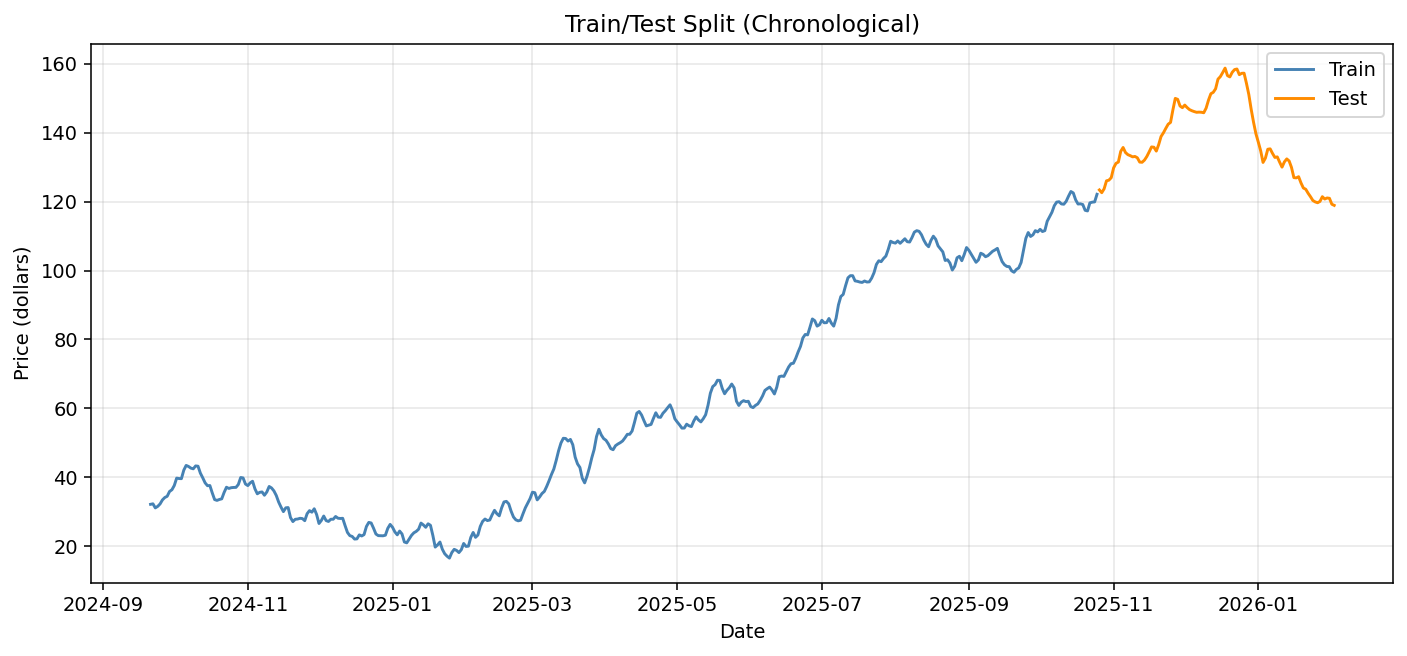

In [5]:
# CELL 5 — Train/Test Split (Chronological) + Plot

split_idx = int(len(ts) * 0.8)
train = ts.iloc[:split_idx]
test  = ts.iloc[split_idx:]

print("Train size:", len(train), "|", train.index.min(), "→", train.index.max())
print("Test size :", len(test),  "|", test.index.min(),  "→", test.index.max())

plt.figure()
plt.plot(train, label="Train", color="steelblue")
plt.plot(test, label="Test", color="darkorange")
plt.title("Train/Test Split (Chronological)")
plt.xlabel("Date")
plt.ylabel("Price (dollars)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [6]:
# CELL 6 — ARIMA Grid Search (p=0..8, d=0..2, q=0..8) using AIC + show Top 10

p_range = range(0, 9)
d_range = range(0, 3)
q_range = range(0, 9)

best_aic = float("inf")
best_order = None
best_fit = None
rows = []

for p in p_range:
    for d in d_range:
        for q in q_range:
            try:
                fit = ARIMA(train, order=(p, d, q)).fit()
                aic = fit.aic
                rows.append((p, d, q, aic))

                if aic < best_aic:
                    best_aic = aic
                    best_order = (p, d, q)
                    best_fit = fit
            except Exception:
                continue

results_df = pd.DataFrame(rows, columns=["p", "d", "q", "AIC"]).sort_values("AIC").reset_index(drop=True)

print("Successful models:", len(results_df))
print("Best ARIMA order:", best_order)
print("Best AIC:", best_aic)

print("\nTop 10 models by AIC:")
results_df.head(10)

Successful models: 242
Best ARIMA order: (3, 1, 4)
Best AIC: 1125.3801551359672

Top 10 models by AIC:


,p,d,q,AIC
0,3,1,4,1125.380155
1,3,2,5,1125.716373
2,0,2,2,1126.428326
3,3,1,3,1127.307602
4,4,2,6,1127.341129
5,0,2,5,1127.627722
6,0,1,5,1127.791044
7,0,1,1,1127.858953
8,1,2,3,1127.893035
9,6,1,3,1127.940083


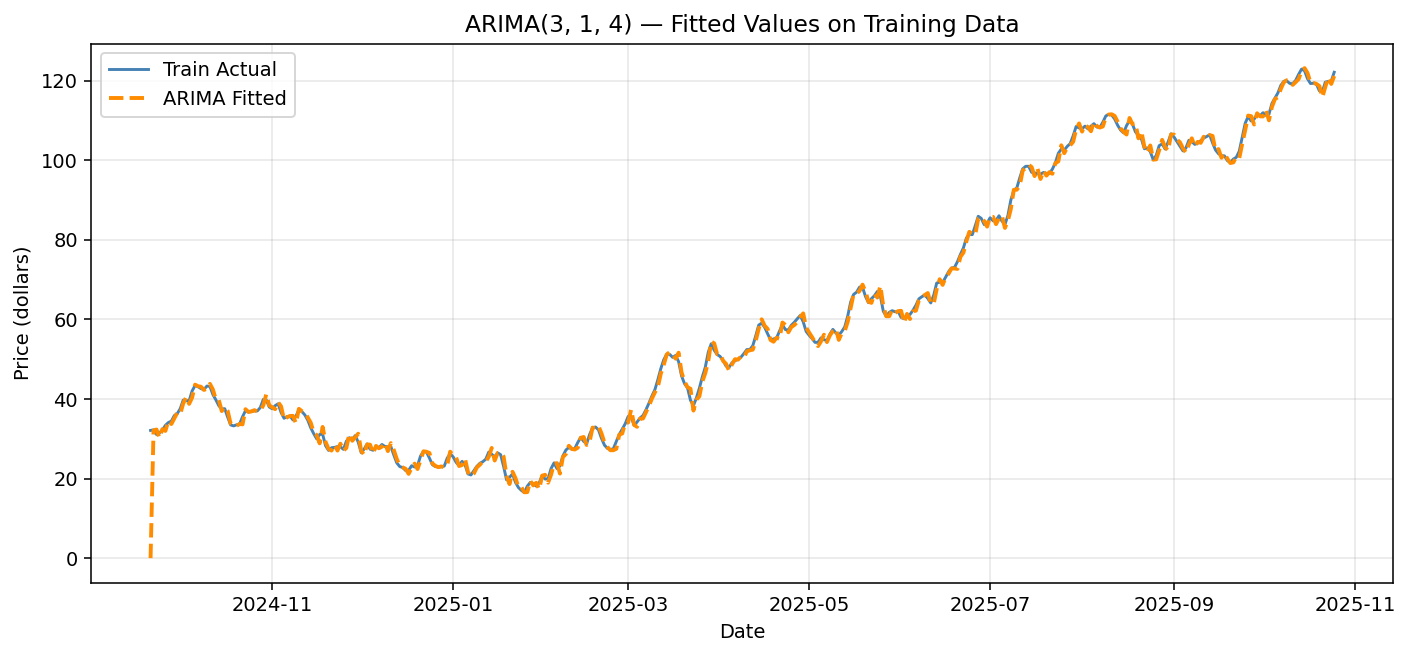

In [7]:
# CELL 7 — ARIMA Model Fit Plot (Train Actual vs Fitted)

fitted = best_fit.fittedvalues

plt.figure()
plt.plot(train, label="Train Actual", color="steelblue")
plt.plot(fitted, "--", label="ARIMA Fitted", color="darkorange", linewidth=2)

plt.title(f"ARIMA{best_order} — Fitted Values on Training Data")
plt.xlabel("Date")
plt.ylabel("Price (dollars)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

ARIMA RMSE (walk-forward): 1.1095453310006522
ARIMA MAE  (walk-forward): 0.8563491755462295

ARIMA RMSE (direct forecast): 18.6408875169387
ARIMA MAE  (direct forecast): 15.135536339956356


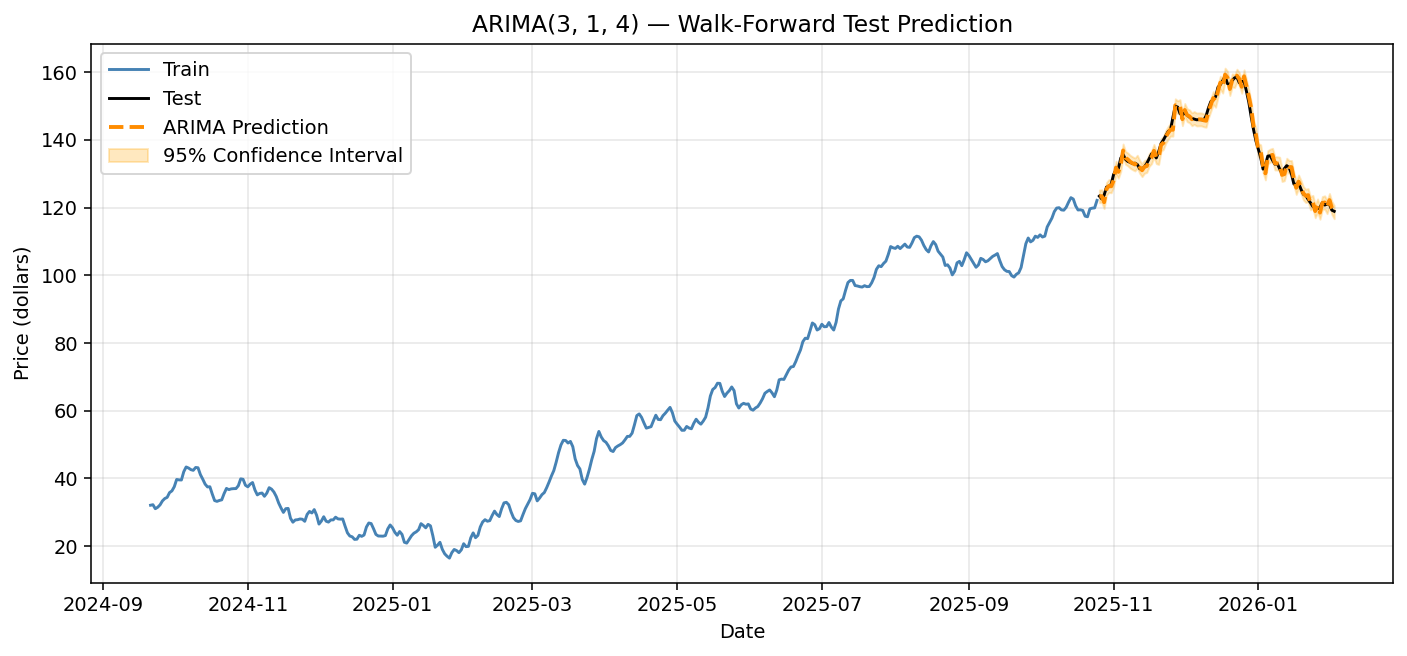

In [19]:
# CELL 8 — ARIMA Walk-Forward Test Prediction + Direct Forecast RMSE/MAE

history = train.copy()

pred_list = []
lower_list = []
upper_list = []

for t in range(len(test)):

    step_model = ARIMA(history, order=best_order).fit()
    step_forecast = step_model.get_forecast(steps=1)

    yhat = step_forecast.predicted_mean.iloc[0]
    ci = step_forecast.conf_int().iloc[0]

    pred_list.append(yhat)
    lower_list.append(ci[0])
    upper_list.append(ci[1])

    # update history with real observation
    history = pd.concat([history, test.iloc[t:t+1]])

pred = pd.Series(pred_list, index=test.index)
pred_lower = pd.Series(lower_list, index=test.index)
pred_upper = pd.Series(upper_list, index=test.index)


# Walk-forward metrics

rmse_arima = sqrt(mean_squared_error(test, pred))
mae_arima  = mean_absolute_error(test, pred)

print("ARIMA RMSE (walk-forward):", rmse_arima)
print("ARIMA MAE  (walk-forward):", mae_arima)



# Direct multi-step forecast metrics (NO plot)

arima_direct = ARIMA(train, order=best_order).fit()

direct_fc = arima_direct.get_forecast(steps=len(test))
pred_direct = direct_fc.predicted_mean
pred_direct.index = test.index

rmse_direct = sqrt(mean_squared_error(test, pred_direct))
mae_direct  = mean_absolute_error(test, pred_direct)

print("\nARIMA RMSE (direct forecast):", rmse_direct)
print("ARIMA MAE  (direct forecast):", mae_direct)


# -----------------------------
# Walk-forward plot
# -----------------------------
plt.figure()

plt.plot(train, label="Train", color="steelblue")
plt.plot(test, label="Test", color="black")

plt.plot(pred, "--", label="ARIMA Prediction", color="darkorange", linewidth=2)

plt.fill_between(
    test.index,
    pred_lower,
    pred_upper,
    alpha=0.25,
    color="orange",
    label="95% Confidence Interval"
)

plt.title(f"ARIMA{best_order} — Walk-Forward Test Prediction")
plt.xlabel("Date")
plt.ylabel("Price (dollars)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

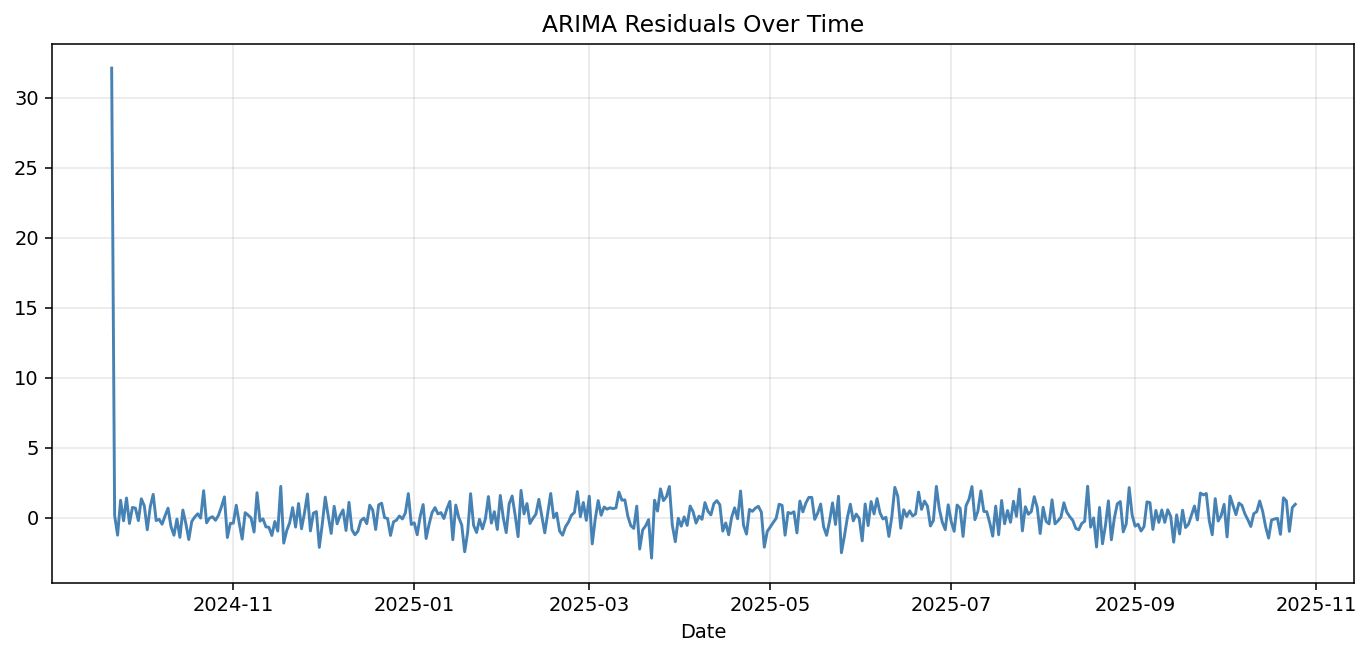

<Figure size 1680x700 with 0 Axes>

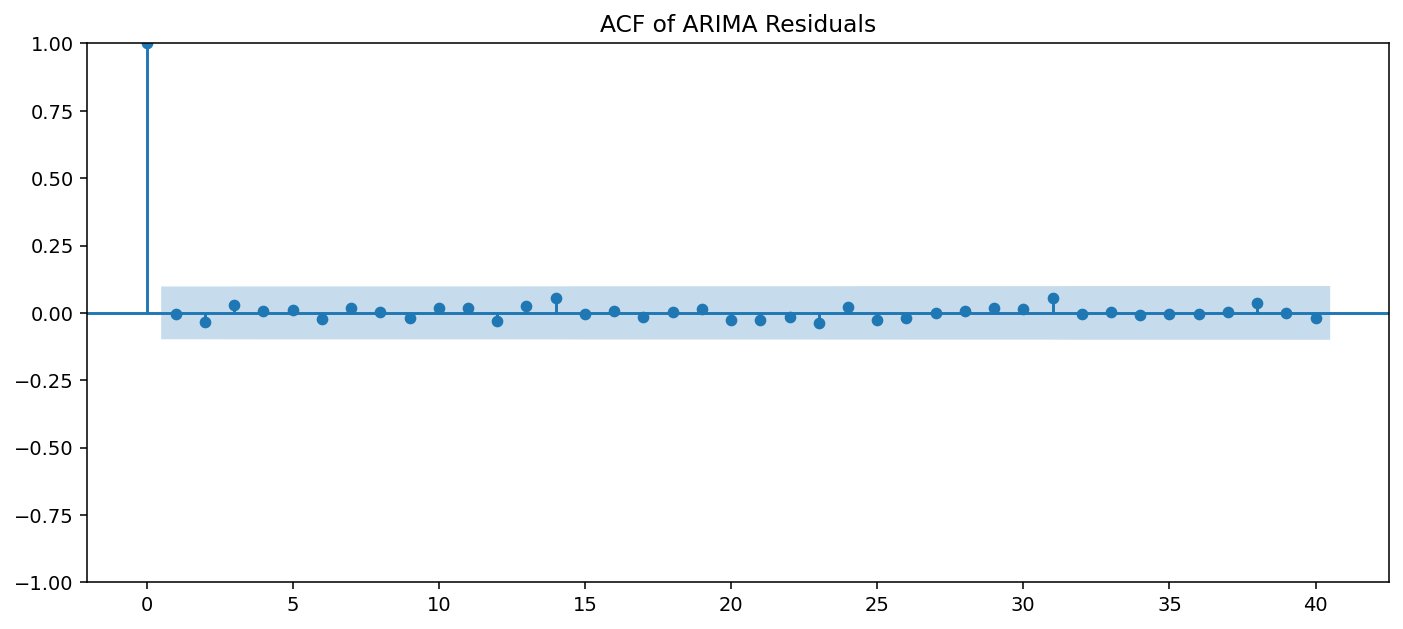

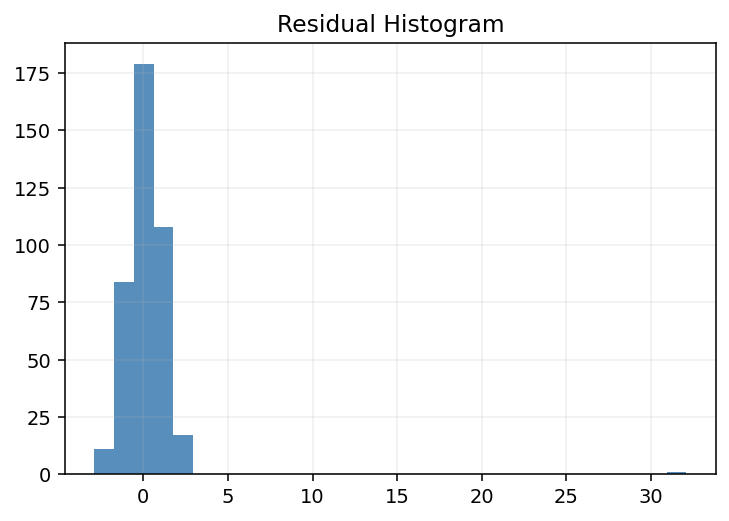

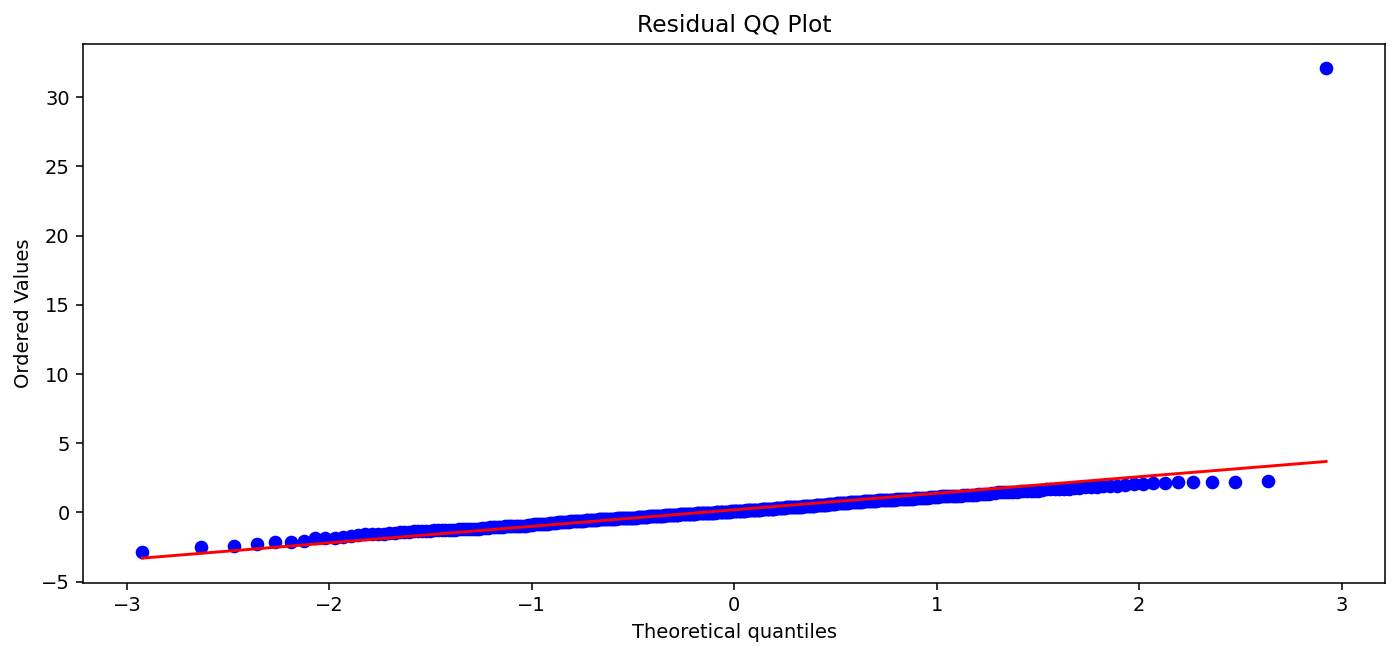

In [10]:
# CELL 9 — ARIMA Residual Diagnostics (Required)

arima_fit = ARIMA(train, order=best_order).fit()
resid = arima_fit.resid.dropna()

# Residuals over time
plt.figure()
plt.plot(resid, color="steelblue")
plt.title("ARIMA Residuals Over Time")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.show()

# Residual ACF
plt.figure()
plot_acf(resid, lags=40)
plt.title("ACF of ARIMA Residuals")
plt.show()

# Histogram of residuals
plt.figure(figsize=(6,4), dpi=140)
plt.hist(resid, bins=30, color="steelblue", alpha=0.9)
plt.title("Residual Histogram")
plt.grid(alpha=0.2)
plt.show()

# QQ plot
stats.probplot(resid, dist="norm", plot=plt)
plt.title("Residual QQ Plot")
plt.show()

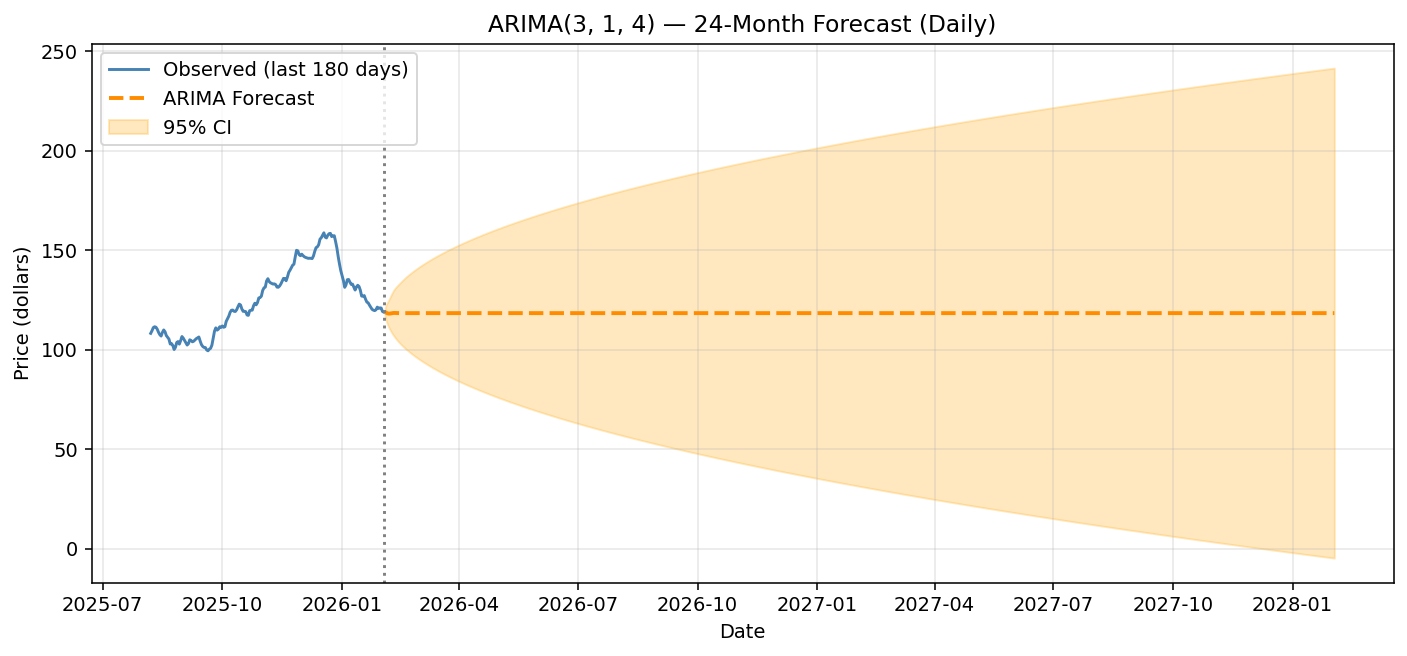

In [12]:
# CELL 10 — ARIMA Final 24-Month Forecast (730 days) + 95% CI (Clean Plot)

final_arima = ARIMA(ts, order=best_order).fit()

steps = 730  # 24 months ≈ 730 daily points
fc_res = final_arima.get_forecast(steps=steps)

fc_mean = fc_res.predicted_mean
fc_ci = fc_res.conf_int()

lookback_days = 180
recent = ts.iloc[-lookback_days:]

plt.figure()
plt.plot(recent.index, recent.values, label=f"Observed (last {lookback_days} days)", color="steelblue")
plt.plot(fc_mean.index, fc_mean.values, "--", label="ARIMA Forecast", color="darkorange", linewidth=2)

plt.fill_between(
    fc_ci.index,
    fc_ci.iloc[:, 0],
    fc_ci.iloc[:, 1],
    alpha=0.25,
    color="orange",
    label="95% CI"
)

plt.axvline(ts.index[-1], color="gray", linestyle=":")
plt.title(f"ARIMA{best_order} — 24-Month Forecast (Daily)")
plt.xlabel("Date")
plt.ylabel("Price (dollars)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
# CELL 11 — LSTM Prep: Scale Data + Sequence Builder

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled  = scaler.transform(test.values.reshape(-1, 1))

def make_sequences(arr2d, window):
    X, y = [], []
    for i in range(window, len(arr2d)):
        X.append(arr2d[i-window:i, 0])
        y.append(arr2d[i, 0])
    X = np.array(X).reshape(-1, window, 1)
    y = np.array(y).reshape(-1, 1)
    return X, y

print("Ready: train_scaled/test_scaled + make_sequences()")

Ready: train_scaled/test_scaled + make_sequences()


In [14]:
# CELL 12 — LSTM Small Grid Search (time-series safe) to pick best hyperparameters
# (kept small so it runs fast and looks clean)

def build_lstm(window, units, dropout):
    model = Sequential([
        LSTM(units, input_shape=(window, 1)),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

# time-consistent validation split inside TRAIN (last 20% for validation)
val_cut = int(len(train_scaled) * 0.8)
train_part = train_scaled[:val_cut]
val_part   = train_scaled[val_cut:]

param_grid = {
    "window":  [20, 30],
    "units":   [32, 64],
    "dropout": [0.1, 0.2],
    "batch":   [16, 32]
}

best_val_rmse = float("inf")
best_params = None

for window in param_grid["window"]:
    X_tr, y_tr = make_sequences(train_part, window)
    X_va, y_va = make_sequences(val_part, window)

    for units in param_grid["units"]:
        for dropout in param_grid["dropout"]:
            for batch in param_grid["batch"]:

                model = build_lstm(window, units, dropout)
                es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

                model.fit(
                    X_tr, y_tr,
                    validation_data=(X_va, y_va),
                    epochs=150,
                    batch_size=batch,
                    callbacks=[es],
                    verbose=0
                )

                va_pred = model.predict(X_va, verbose=0)
                va_pred_inv = scaler.inverse_transform(va_pred).flatten()
                y_va_inv    = scaler.inverse_transform(y_va).flatten()

                val_rmse = sqrt(mean_squared_error(y_va_inv, va_pred_inv))

                if val_rmse < best_val_rmse:
                    best_val_rmse = val_rmse
                    best_params = (window, units, dropout, batch)

print("Best LSTM params (window, units, dropout, batch):", best_params)
print("Best validation RMSE:", best_val_rmse)

Best LSTM params (window, units, dropout, batch): (20, 64, 0.1, 16)
Best validation RMSE: 1.9765122629436465


Epoch 1/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0824 - val_loss: 0.0016
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0051 - val_loss: 0.0016
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0028 - val_loss: 0.0013
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0027 - val_loss: 0.0043
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0020 - val_loss: 0.0041
Epoch 6/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0019 - val_loss: 0.0046
Epoch 7/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0019 - val_loss: 0.0063
Epoch 8/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0019 - val_loss: 0.0046
Epoch 9/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0018 - val_loss: 0.0042
Epoch 10/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0018 - val_loss: 0.0039
Epoch 11/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0017 - val_loss: 0.0031
Epoch 12/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

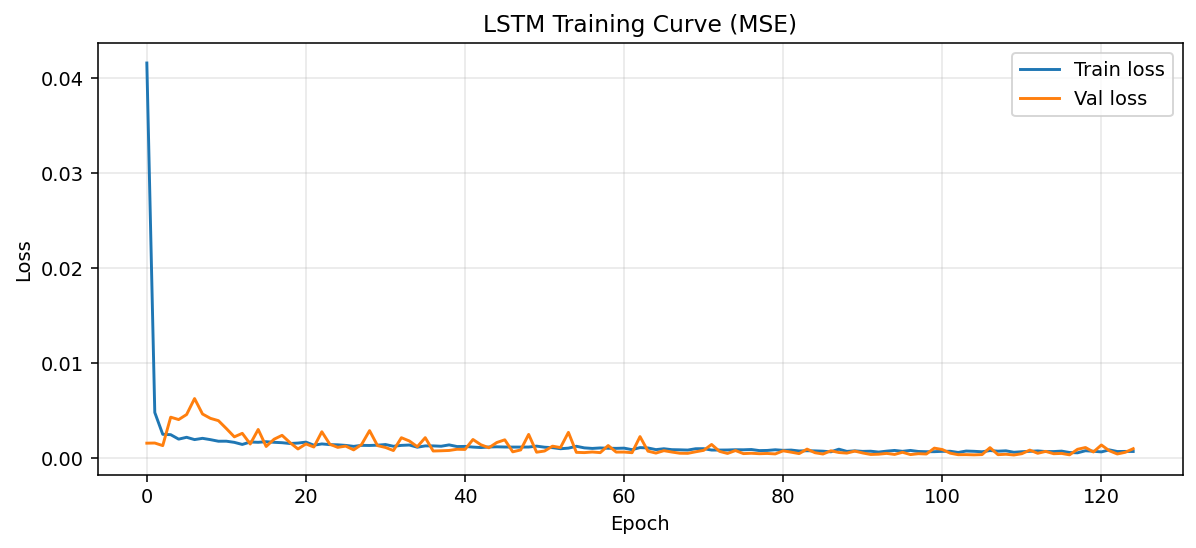

LSTM RMSE (test): 2.3712145752710296
LSTM MAE  (test): 1.9465848022460939


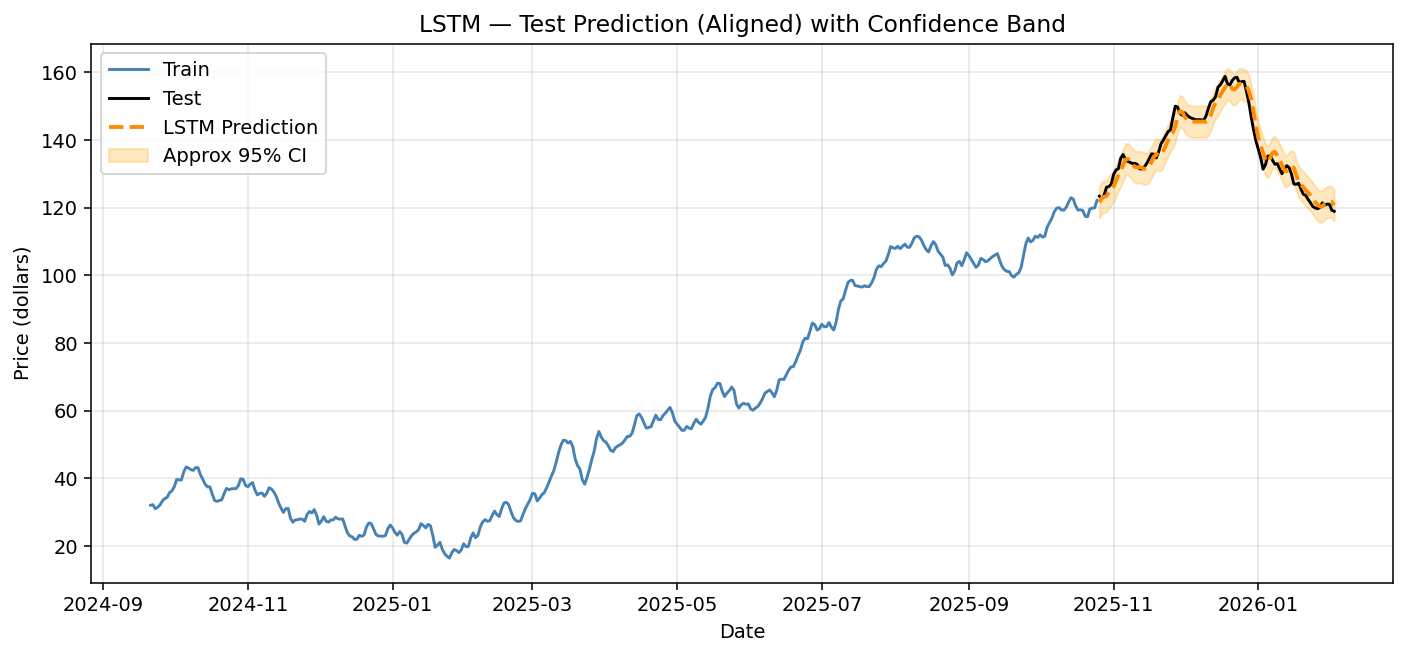

In [15]:
# CELL 13 — Train Final LSTM + Test Prediction (Aligned) + RMSE/MAE + Neat Plot

window, units, dropout, batch = best_params

# build final model
final_lstm = build_lstm(window, units, dropout)
es = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

# train on FULL train sequences
X_train, y_train = make_sequences(train_scaled, window)

history = final_lstm.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=batch,
    callbacks=[es],
    verbose=1
)

# training curve
plt.figure(figsize=(10,4), dpi=140)
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.title("LSTM Training Curve (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# aligned test prediction: use last window days of train + full test
combined = np.concatenate([train_scaled[-window:], test_scaled], axis=0)
X_all, y_all = make_sequences(combined, window)

pred_scaled = final_lstm.predict(X_all, verbose=0)
pred_test = scaler.inverse_transform(pred_scaled).flatten()

# metrics (aligned to full test)
rmse_lstm = sqrt(mean_squared_error(test.values, pred_test))
mae_lstm  = mean_absolute_error(test.values, pred_test)

print("LSTM RMSE (test):", rmse_lstm)
print("LSTM MAE  (test):", mae_lstm)

# approx 95% CI using RMSE (simple + acceptable for assignment)
ci = 1.96 * rmse_lstm
lower = pred_test - ci
upper = pred_test + ci

# plot
plt.figure()

plt.plot(train.index, train.values, label="Train", color="steelblue")
plt.plot(test.index, test.values, label="Test", color="black")

plt.plot(test.index, pred_test, "--", label="LSTM Prediction", color="darkorange", linewidth=2)

plt.fill_between(
    test.index,
    lower,
    upper,
    alpha=0.25,
    color="orange",
    label="Approx 95% CI"
)

plt.title("LSTM — Test Prediction (Aligned) with Confidence Band")
plt.xlabel("Date")
plt.ylabel("Price (dollars)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

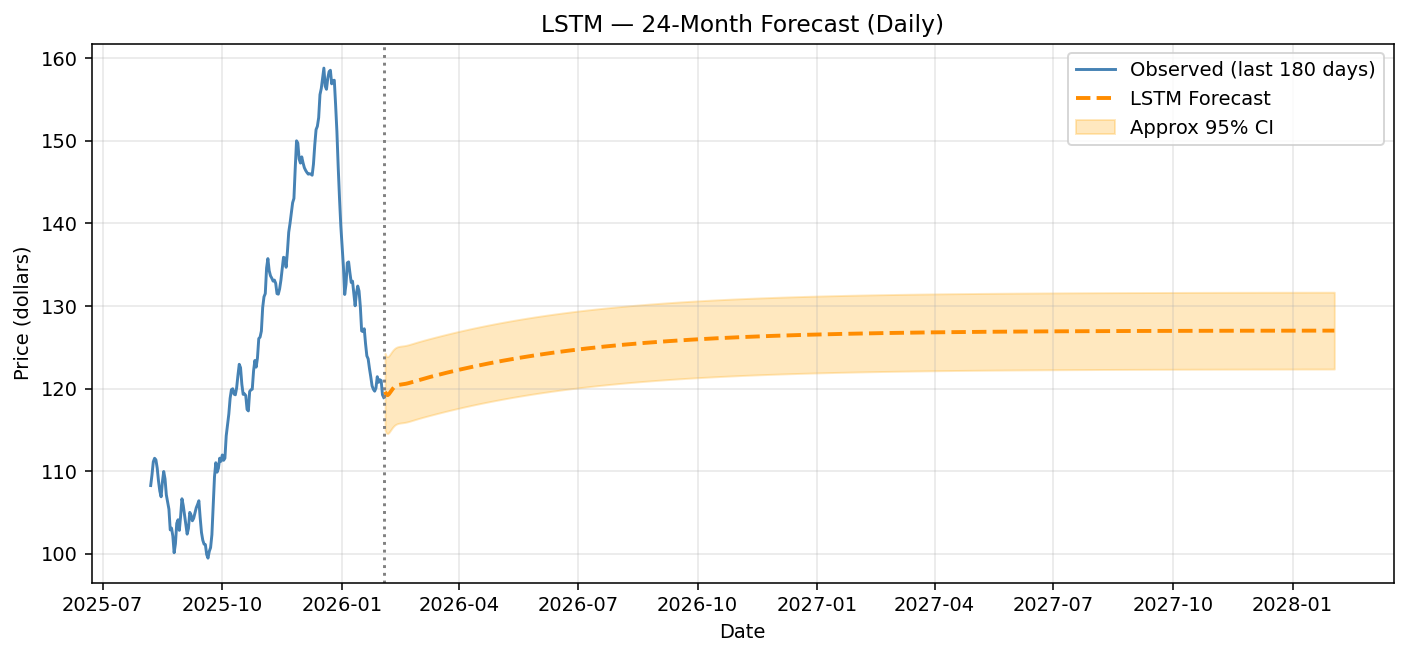

In [16]:
# CELL 14 — LSTM Final 24-Month Forecast (730 days) + Neat Plot + Approx CI

future_steps = 730

# scale FULL series with the SAME scaler (fit on train earlier)
full_scaled = scaler.transform(ts.values.reshape(-1, 1))

# start window = last `window` values
last_window = full_scaled[-window:].reshape(1, window, 1)

future_scaled = []

for _ in range(future_steps):
    nxt = final_lstm.predict(last_window, verbose=0)[0, 0]
    future_scaled.append(nxt)

    # shift window and append new prediction
    last_window = np.append(last_window.flatten()[1:], nxt).reshape(1, window, 1)

future_vals = scaler.inverse_transform(np.array(future_scaled).reshape(-1, 1)).flatten()

future_index = pd.date_range(
    start=ts.index[-1] + pd.Timedelta(days=1),
    periods=future_steps,
    freq="D"
)

# approx CI using test RMSE (kept constant for simplicity)
ci = 1.96 * rmse_lstm
lower_f = future_vals - ci
upper_f = future_vals + ci

lookback_days = 180
recent = ts.iloc[-lookback_days:]

plt.figure()

plt.plot(recent.index, recent.values, label=f"Observed (last {lookback_days} days)", color="steelblue")
plt.plot(future_index, future_vals, "--", label="LSTM Forecast", color="darkorange", linewidth=2)

plt.fill_between(
    future_index,
    lower_f,
    upper_f,
    alpha=0.25,
    color="orange",
    label="Approx 95% CI"
)

plt.axvline(ts.index[-1], color="gray", linestyle=":")

plt.title("LSTM — 24-Month Forecast (Daily)")
plt.xlabel("Date")
plt.ylabel("Price (dollars)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


Model Performance Comparison
                     Model    RMSE     MAE
0     ARIMA (Walk-Forward)   1.110   0.856
1  ARIMA (Direct Forecast)  18.641  15.136
2                     LSTM   2.371   1.947
Saved: report_figures/Fig09_model_comparison_rmse.png


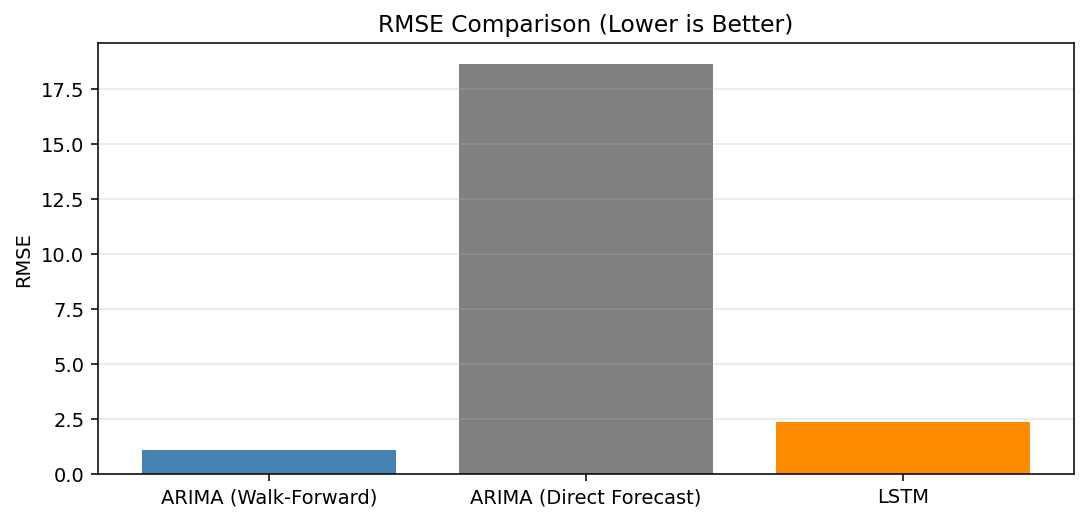

Saved: report_figures/Fig10_model_comparison_mae.png


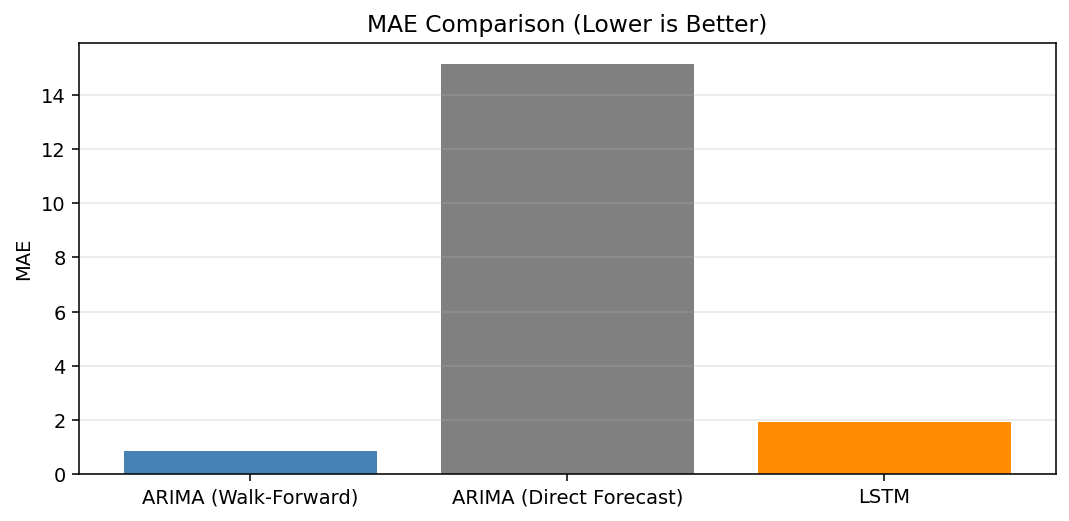

In [36]:
# CELL 15 — Final Model Comparison (ARIMA Walk-forward vs Direct vs LSTM)

comparison = pd.DataFrame({
    "Model": [
        "ARIMA (Walk-Forward)",
        "ARIMA (Direct Forecast)",
        "LSTM"
    ],
    "RMSE": [
        rmse_arima,
        rmse_direct,
        rmse_lstm
    ],
    "MAE": [
        mae_arima,
        mae_direct,
        mae_lstm
    ]
})

# round values for cleaner display
comparison["RMSE"] = comparison["RMSE"].round(3)
comparison["MAE"] = comparison["MAE"].round(3)

print("\nModel Performance Comparison")
print(comparison)


# RMSE chart
plt.figure(figsize=(9,4))

plt.bar(
    comparison["Model"],
    comparison["RMSE"],
    color=["steelblue","gray","darkorange"]
)

plt.title("RMSE Comparison (Lower is Better)")
plt.ylabel("RMSE")
plt.grid(axis="y", alpha=0.3)
save_fig("Fig09_model_comparison_rmse.png")
plt.show()


# MAE chart
plt.figure(figsize=(9,4))

plt.bar(
    comparison["Model"],
    comparison["MAE"],
    color=["steelblue","gray","darkorange"]
)

plt.title("MAE Comparison (Lower is Better)")
plt.ylabel("MAE")
plt.grid(axis="y", alpha=0.3)
save_fig("Fig10_model_comparison_mae.png")

plt.show()

In [22]:
# STEP 1 — Create a folder + helper to save figures (Colab)

import os
os.makedirs("report_figures", exist_ok=True)

def save_fig(filename):
    path = os.path.join("report_figures", filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)

Saved: report_figures/Fig01_rolling60_trend.png


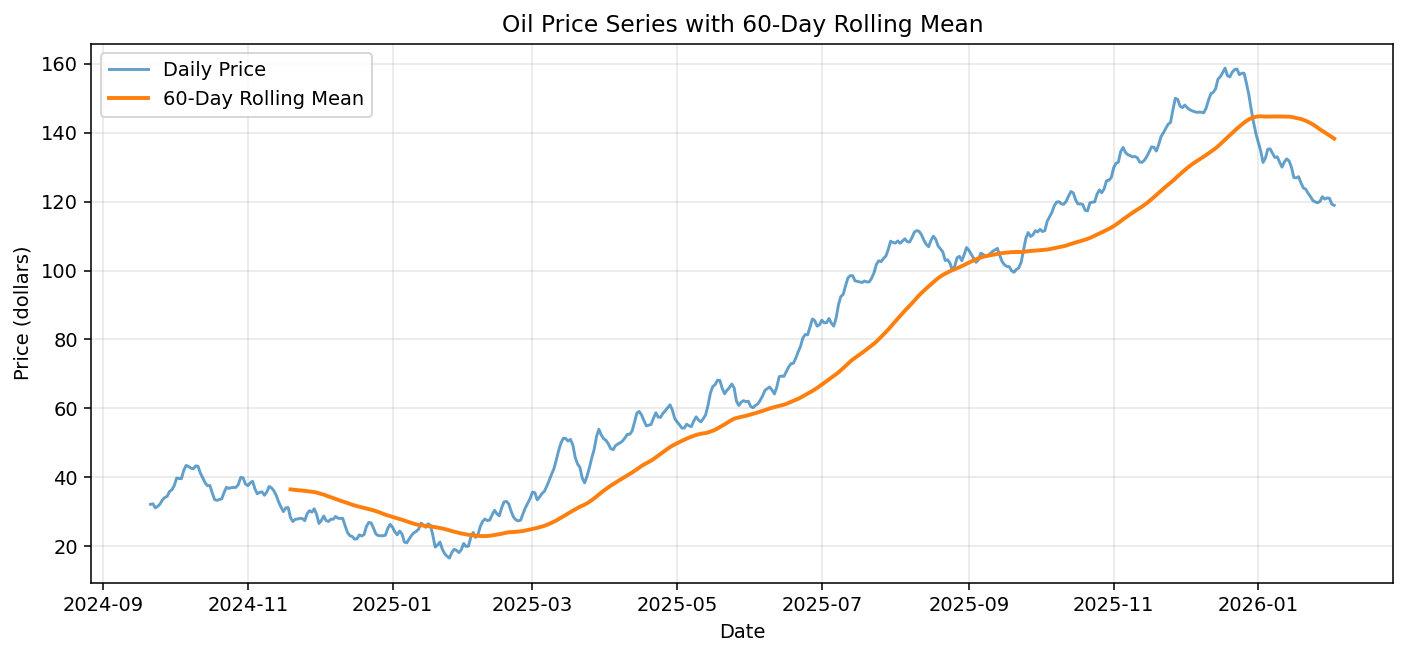

In [23]:
rolling_60 = ts.rolling(window=60).mean()

plt.figure(figsize=(12,5), dpi=140)
plt.plot(ts, label="Daily Price", alpha=0.7)
plt.plot(rolling_60, label="60-Day Rolling Mean", linewidth=2)

plt.title("Oil Price Series with 60-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Price (dollars)")
plt.legend()
plt.grid(alpha=0.3)

save_fig("Fig01_rolling60_trend.png")
plt.show()

Saved: report_figures/Fig02_monthly_counts.png


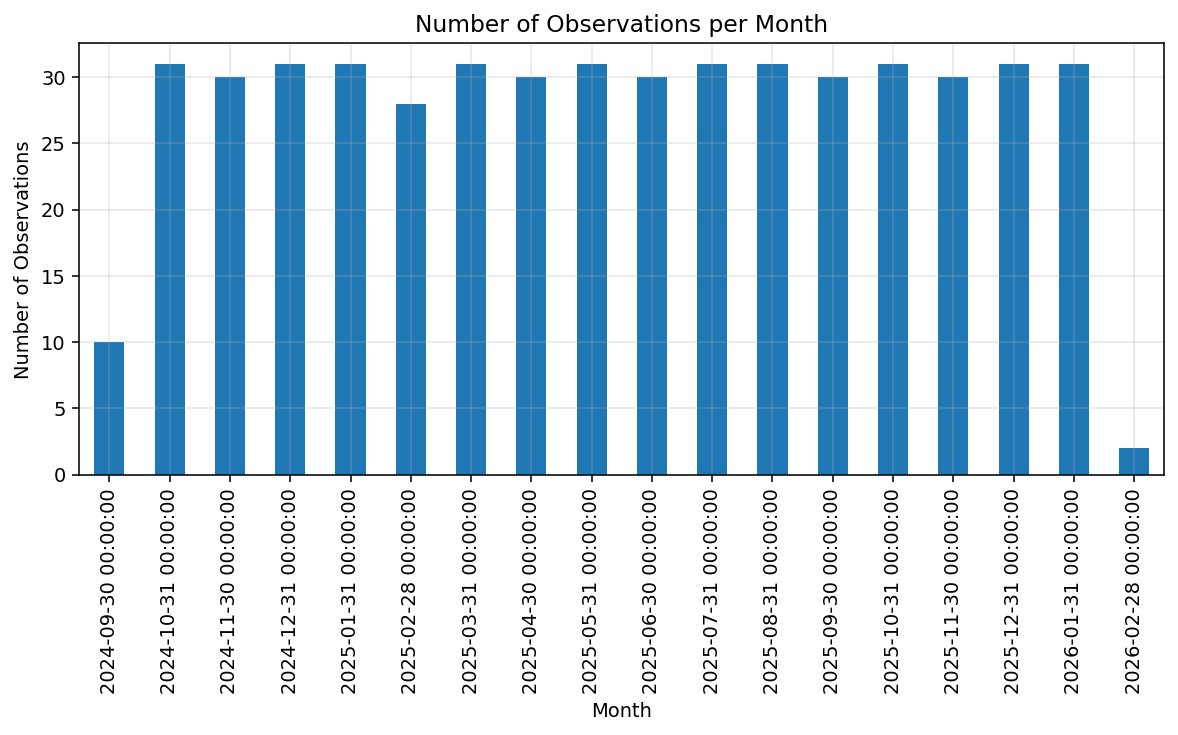

In [24]:
monthly_counts = ts.resample("M").count()

plt.figure(figsize=(10,4), dpi=140)
monthly_counts.plot(kind="bar")

plt.title("Number of Observations per Month")
plt.xlabel("Month")
plt.ylabel("Number of Observations")
plt.grid(alpha=0.3)

save_fig("Fig02_monthly_counts.png")
plt.show()

Saved: report_figures/Fig03_train_test_split.png


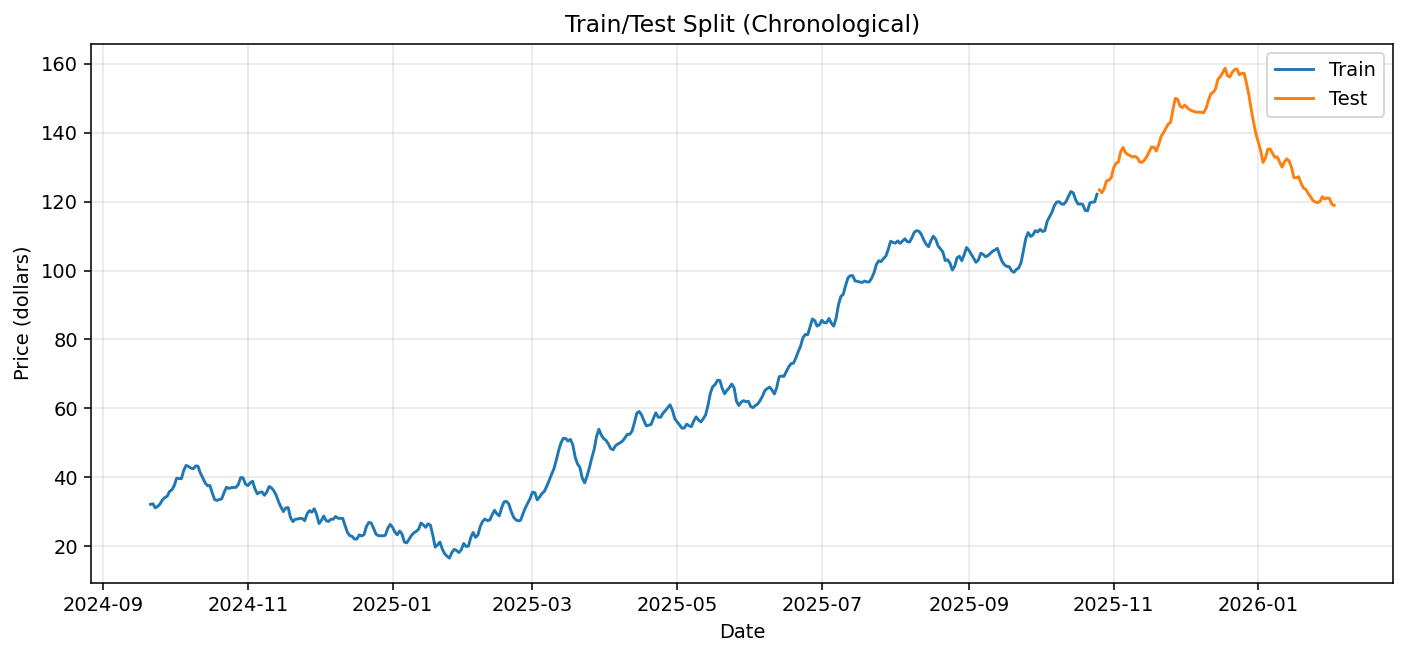

In [25]:
plt.figure(figsize=(12,5), dpi=140)
plt.plot(train, label="Train")
plt.plot(test, label="Test")

plt.title("Train/Test Split (Chronological)")
plt.xlabel("Date")
plt.ylabel("Price (dollars)")
plt.legend()
plt.grid(alpha=0.3)

save_fig("Fig03_train_test_split.png")
plt.show()

Saved: report_figures/Fig04_arima_fit_train.png


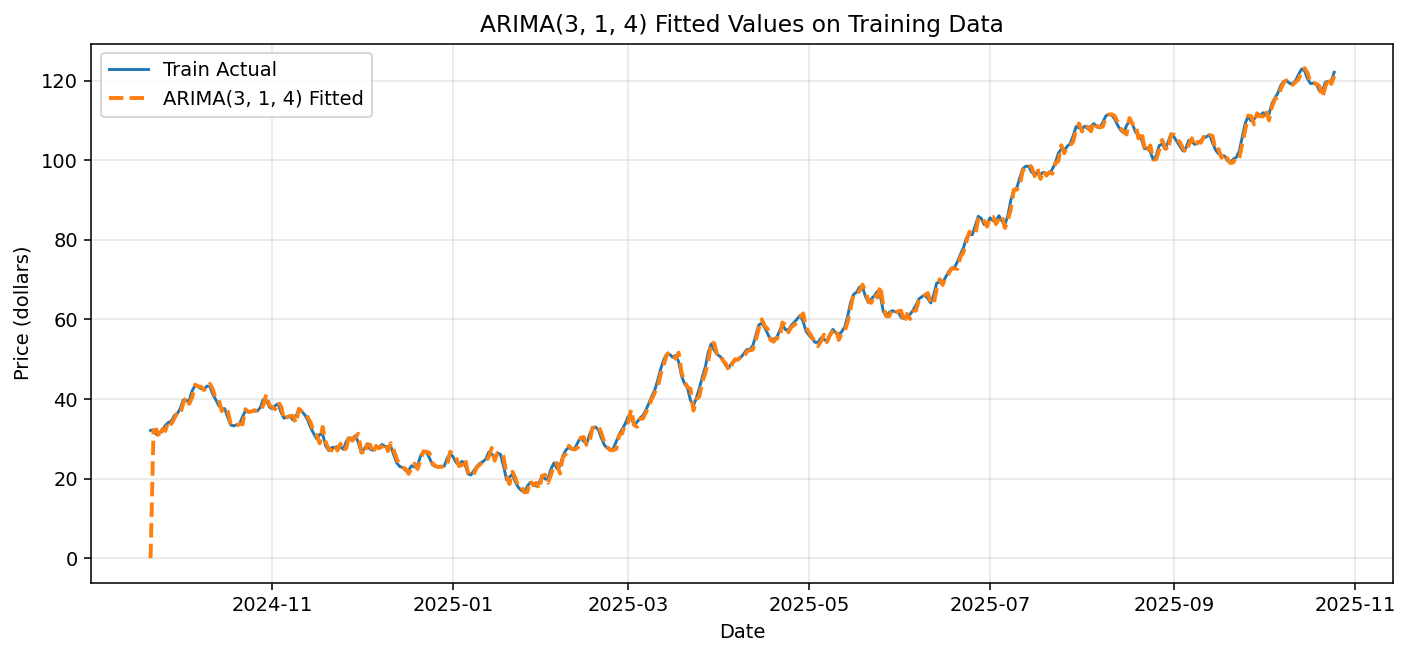

In [26]:
fitted = best_fit.fittedvalues  # or best_model.fittedvalues if your variable name is best_model

plt.figure(figsize=(12,5), dpi=140)
plt.plot(train, label="Train Actual")
plt.plot(fitted, "--", label=f"ARIMA{best_order} Fitted", linewidth=2)

plt.title(f"ARIMA{best_order} Fitted Values on Training Data")
plt.xlabel("Date")
plt.ylabel("Price (dollars)")
plt.legend()
plt.grid(alpha=0.3)

save_fig("Fig04_arima_fit_train.png")
plt.show()

Saved: report_figures/Fig05_arima_walkforward_test.png


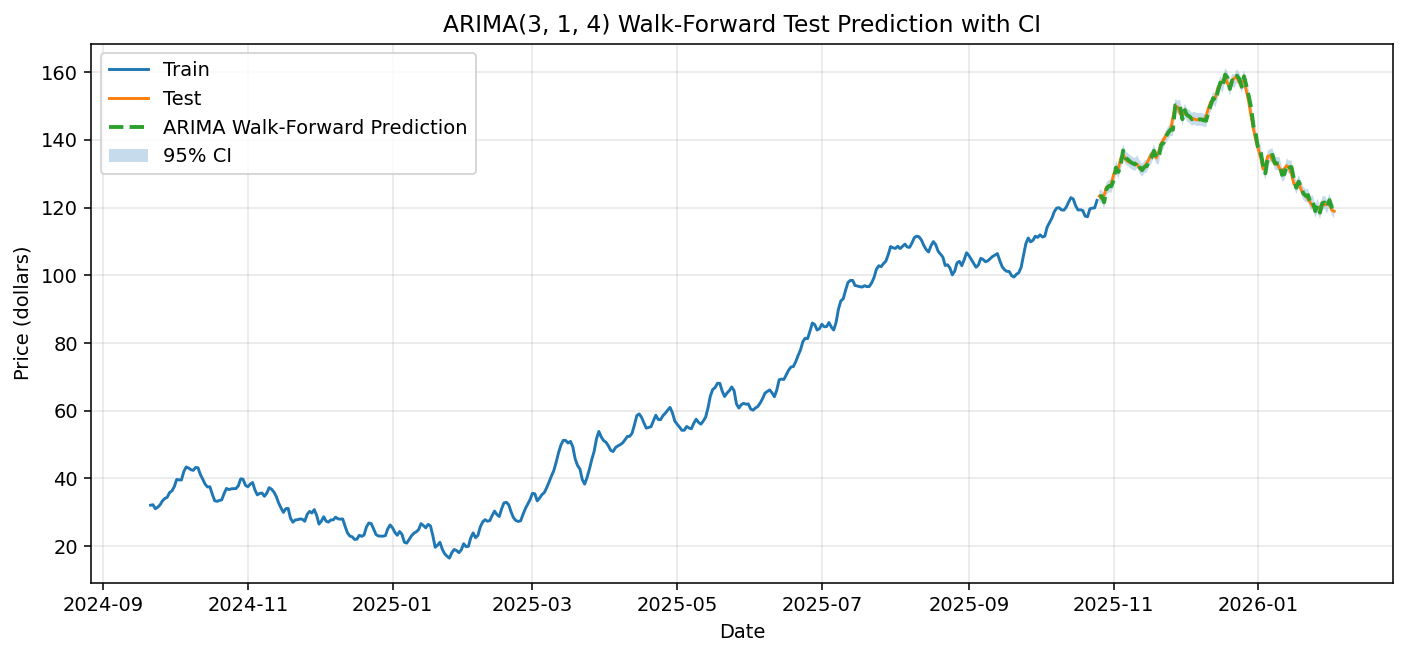

In [28]:
plt.figure(figsize=(12,5), dpi=140)
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(pred, "--", label="ARIMA Walk-Forward Prediction", linewidth=2)

plt.fill_between(
    test.index,
    pred_lower.values,
    pred_upper.values,
    alpha=0.25,
    label="95% CI"
)

plt.title(f"ARIMA{best_order} Walk-Forward Test Prediction with CI")
plt.xlabel("Date")
plt.ylabel("Price (dollars)")
plt.legend()
plt.grid(alpha=0.3)

save_fig("Fig05_arima_walkforward_test.png")
plt.show()

Saved: report_figures/Fig06_arima_residual_acf.png


<Figure size 1680x700 with 0 Axes>

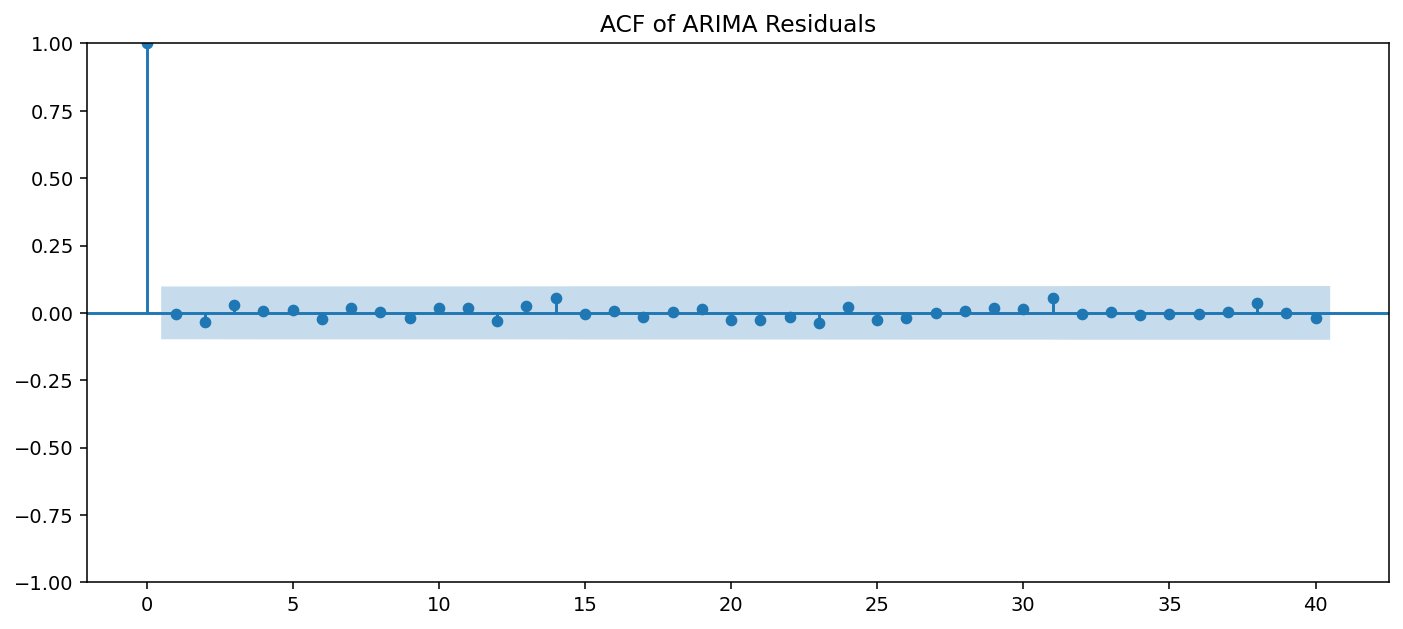

In [29]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,5), dpi=140)
plot_acf(resid, lags=40)
plt.title("ACF of ARIMA Residuals")

save_fig("Fig06_arima_residual_acf.png")
plt.show()

Saved: report_figures/Fig07_arima_24month_forecast.png


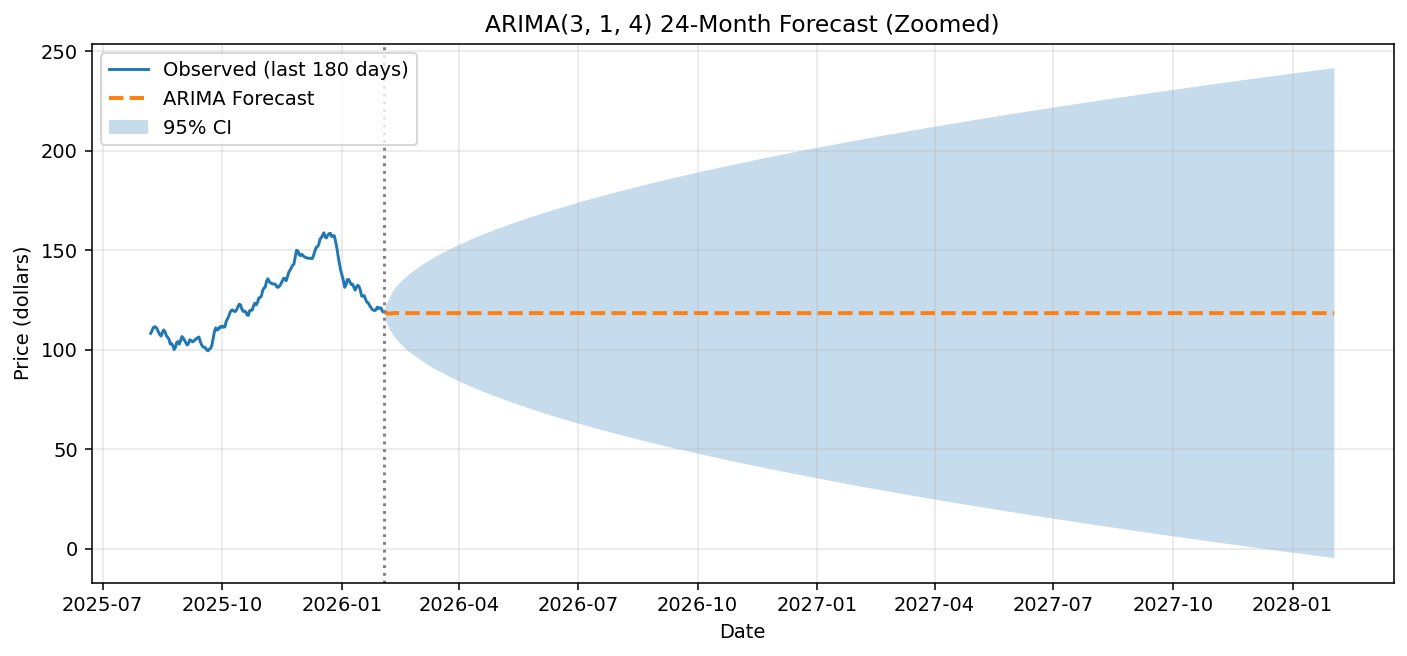

In [30]:
lookback_days = 180
recent = ts.iloc[-lookback_days:]

plt.figure(figsize=(12,5), dpi=140)
plt.plot(recent.index, recent.values, label=f"Observed (last {lookback_days} days)")
plt.plot(fc_mean.index, fc_mean.values, "--", label="ARIMA Forecast", linewidth=2)

plt.fill_between(
    fc_ci.index,
    fc_ci.iloc[:, 0],
    fc_ci.iloc[:, 1],
    alpha=0.25,
    label="95% CI"
)

plt.axvline(ts.index[-1], color="gray", linestyle=":")
plt.title(f"ARIMA{best_order} 24-Month Forecast (Zoomed)")
plt.xlabel("Date")
plt.ylabel("Price (dollars)")
plt.legend()
plt.grid(alpha=0.3)

save_fig("Fig07_arima_24month_forecast.png")
plt.show()

Saved: report_figures/Fig08_lstm_test_prediction.png


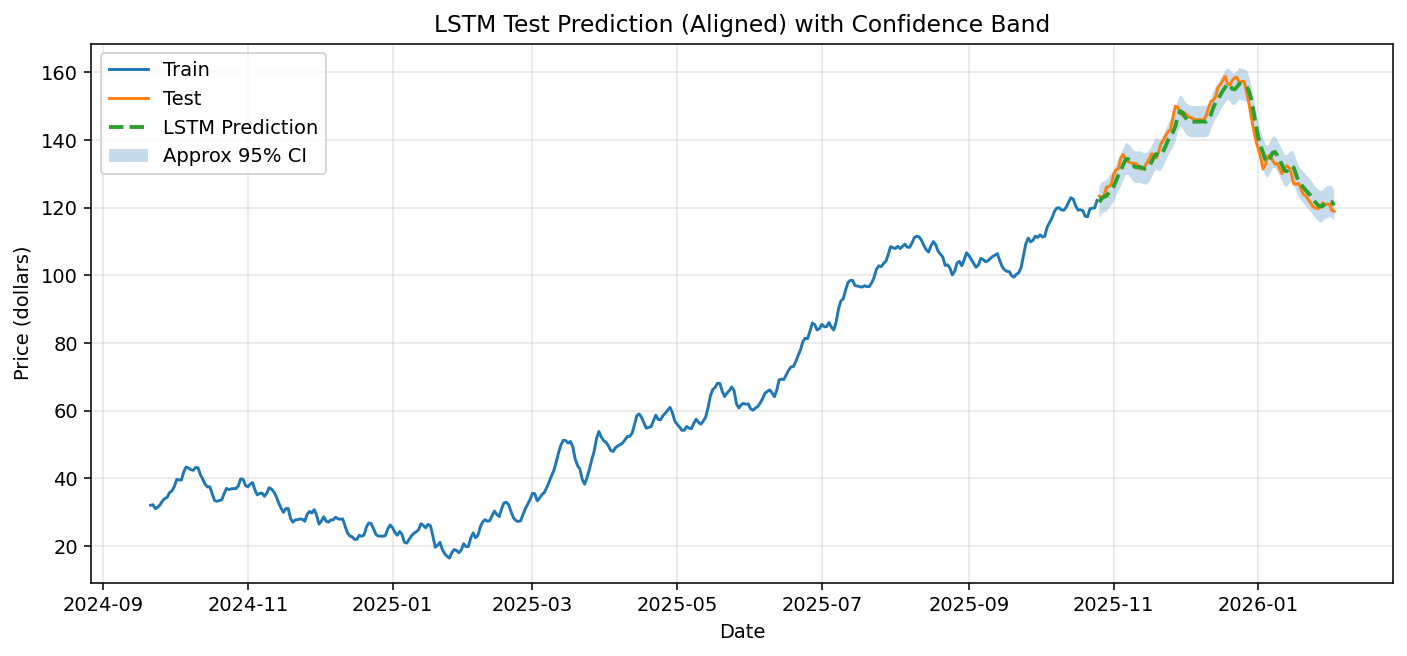

In [31]:
plt.figure(figsize=(12,5), dpi=140)
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Test")
plt.plot(test.index, pred_test, "--", label="LSTM Prediction", linewidth=2)

plt.fill_between(
    test.index,
    lower,
    upper,
    alpha=0.25,
    label="Approx 95% CI"
)

plt.title("LSTM Test Prediction (Aligned) with Confidence Band")
plt.xlabel("Date")
plt.ylabel("Price (dollars)")
plt.legend()
plt.grid(alpha=0.3)

save_fig("Fig08_lstm_test_prediction.png")
plt.show()

Saved: report_figures/Fig09_lstm_24month_forecast.png


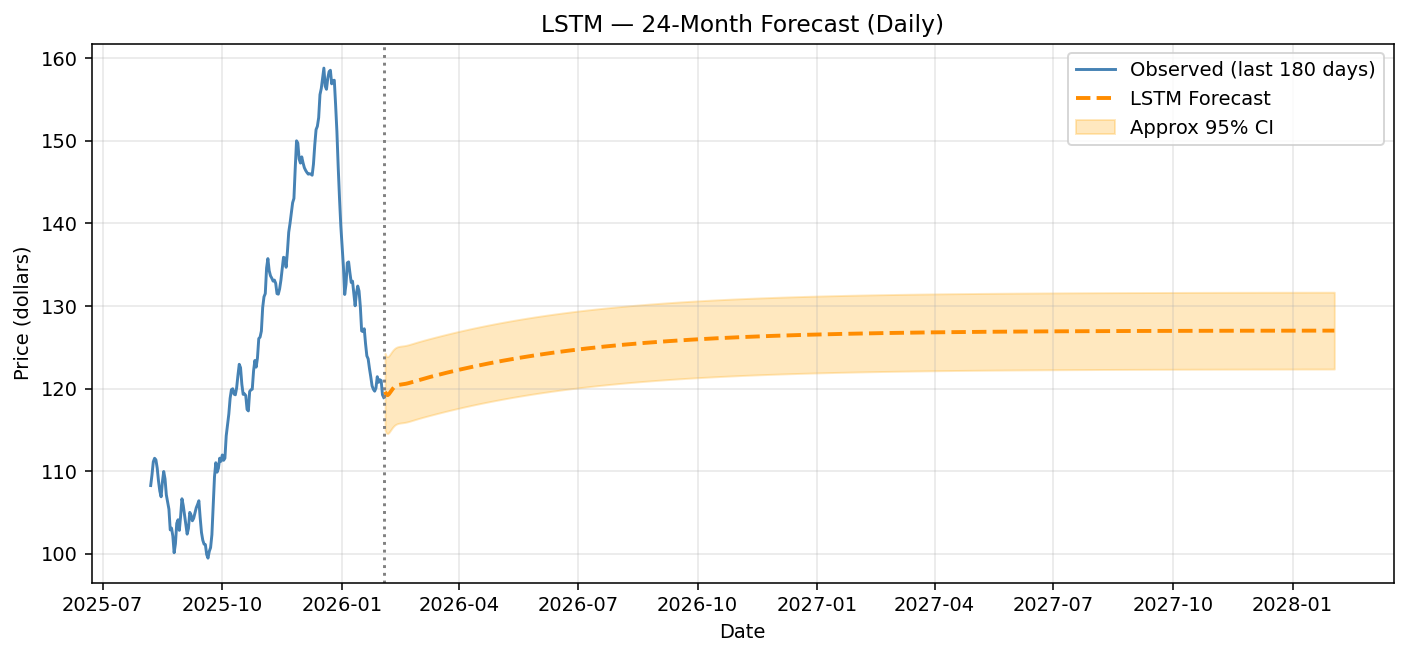

In [34]:
lookback_days = 180
recent = ts.iloc[-lookback_days:]

plt.figure()

plt.plot(recent.index, recent.values, label=f"Observed (last {lookback_days} days)", color="steelblue")
plt.plot(future_index, future_vals, "--", label="LSTM Forecast", color="darkorange", linewidth=2)

plt.fill_between(
    future_index,
    lower_f,
    upper_f,
    alpha=0.25,
    color="orange",
    label="Approx 95% CI"
)

plt.axvline(ts.index[-1], color="gray", linestyle=":")

plt.title("LSTM — 24-Month Forecast (Daily)")
plt.xlabel("Date")
plt.ylabel("Price (dollars)")
plt.legend()
plt.grid(alpha=0.3)
save_fig("Fig09_lstm_24month_forecast.png")

plt.show()

In [37]:
import shutil
from google.colab import files

shutil.make_archive("report_figures", "zip", "report_figures")
files.download("report_figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>